<div style="display: flex; align-items: center;">
    <img alt="udeA logo" height="140px" src="https://github.com/freddyduitama/images/blob/master/logo.png?raw=true" style="width:107px;height:152px; margin-right: 40px;">
    <div style="text-align: center;">
        <h1><b><font color='0B5345'>Trabajo 2: Imagenes médicas</font></b></h1>
        <h2><font color='0B5345'>Luisa Fernanda Enciso - Juan Diego Caguasango</font></h2>
    </div>
</div>


In [37]:
# Importar Librerías
import os 
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, median_filter
from medpy.filter.smoothing import anisotropic_diffusion

<hr>
<h3><strong>2. Filtrado</strong></h3>

Función para aplicar múltiples filtros con variación de parámetros a cada imagen, facilitando el análisis comparativo de sus efectos.

In [ ]:
def normalize_img(img):
    """Normaliza la imagen entre 0 y 1"""
    return (img - np.min(img)) / (np.max(img) - np.min(img))

def procesar_sujeto(carpeta_sujeto):
    """
    Procesa todas las imágenes .nii.gz dentro de carpeta_sujeto/anat:
    - Aplica filtros mediana, gaussiano y anisotrópico
    - Visualiza comparativos para cada imagen
    """
    anat_path = os.path.join(carpeta_sujeto, "anat")
    if not os.path.exists(anat_path):
        print(f"No existe la carpeta anat en {carpeta_sujeto}")
        return
    
    median_sizes = [3, 5]
    gauss_sigmas = [1, 3]
    anisotropic_iters = [2, 6]

    for filename in os.listdir(anat_path):
        if filename.endswith(".nii.gz"):
            file_path = os.path.join(anat_path, filename)
            print(f"Procesando {file_path}")

            # Cargar imagen y corte axial medio
            nii = nib.load(file_path)
            volume = nii.get_fdata()
            slice_idx = volume.shape[2] // 2
            slice_img = volume[:, :, slice_idx]
            norm_img = normalize_img(slice_img)

            # Filtros
            medians = [median_filter(norm_img, size=s) for s in median_sizes]
            gaussians = [gaussian_filter(norm_img, sigma=s) for s in gauss_sigmas]
            anisotropics = [anisotropic_diffusion(norm_img, niter=n) for n in anisotropic_iters]

            # Visualización
            fig, axes = plt.subplots(3, 3, figsize=(15, 12))

            axes[0, 0].imshow(norm_img, cmap='gray')
            axes[0, 0].set_title("Original")
            for i, med in enumerate(medians):
                axes[0, i+1].imshow(med, cmap='gray')
                axes[0, i+1].set_title(f"Mediana ({median_sizes[i]}x{median_sizes[i]})")

            axes[1, 0].imshow(norm_img, cmap='gray')
            axes[1, 0].set_title("Original")
            for i, gauss in enumerate(gaussians):
                axes[1, i+1].imshow(gauss, cmap='gray')
                axes[1, i+1].set_title(f"Gaussiano (σ={gauss_sigmas[i]})")

            axes[2, 0].imshow(norm_img, cmap='gray')
            axes[2, 0].set_title("Original")
            for i, aniso in enumerate(anisotropics):
                axes[2, i+1].imshow(aniso, cmap='gray')
                axes[2, i+1].set_title(f"Anisotrópica ({anisotropic_iters[i]} iter)")

            for ax in axes.ravel():
                ax.axis('off')

            plt.suptitle(f"Sujeto: {os.path.basename(carpeta_sujeto)} - Imagen: {filename}", fontsize=16)
            plt.tight_layout(rect=[0, 0.03, 1, 0.95])
            plt.show()


<h3>Sujeto Uno<h3>

Procesando DATA\BIDS\sub-0001\anat\sub-0001_FLAIR.nii.gz


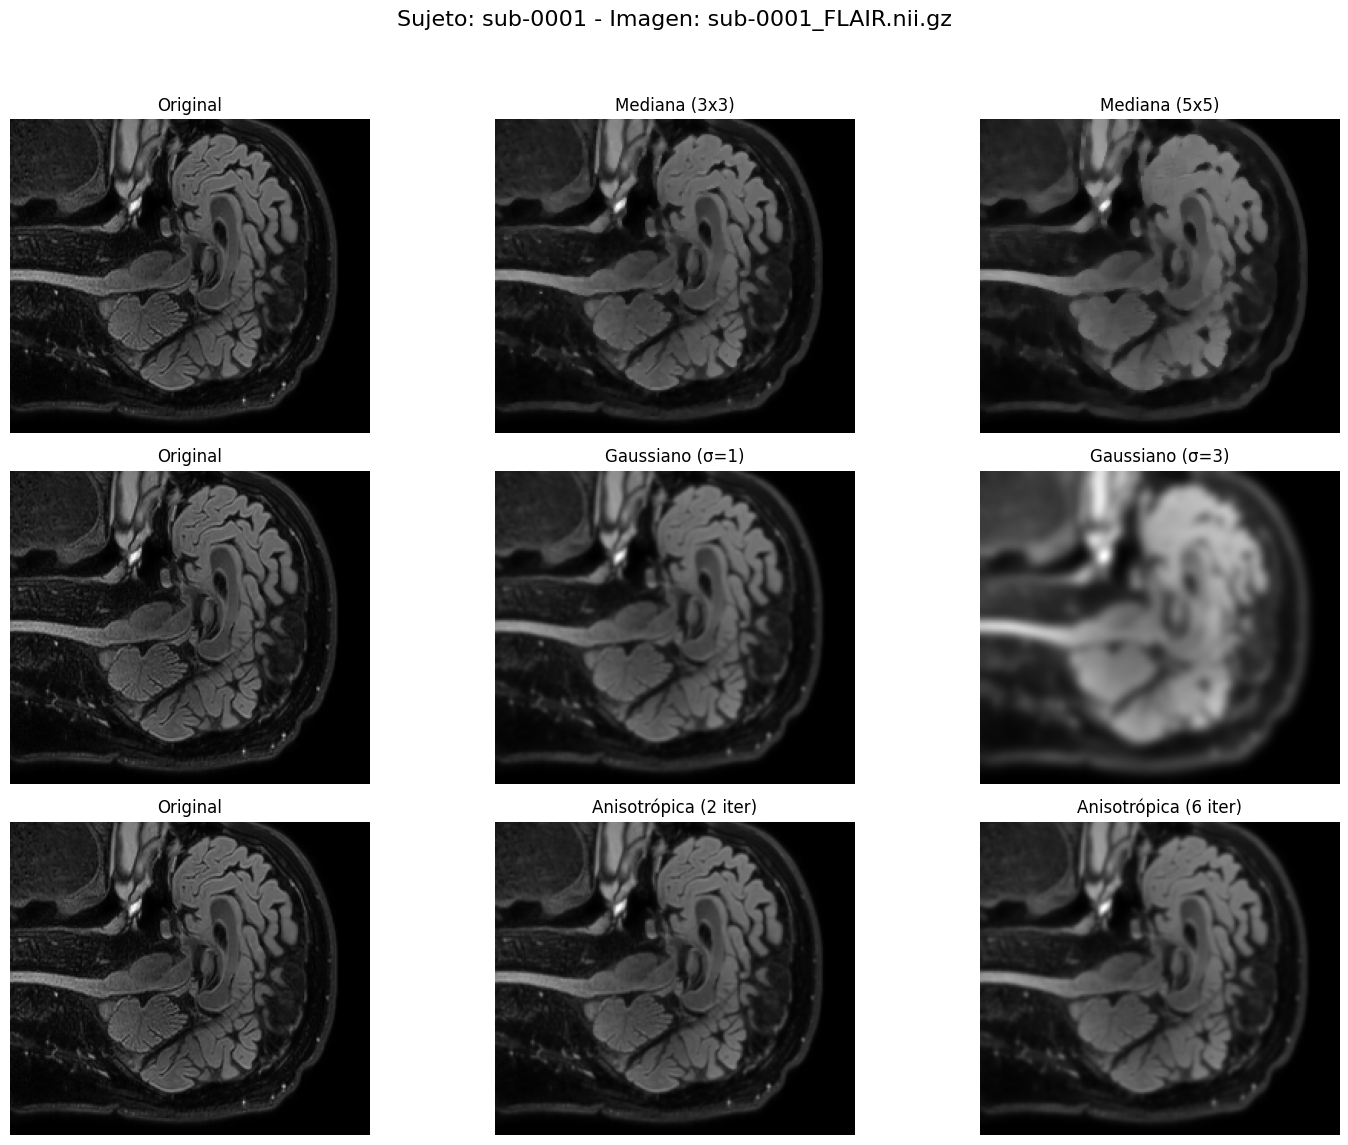

Procesando DATA\BIDS\sub-0001\anat\sub-0001_T1w.nii.gz


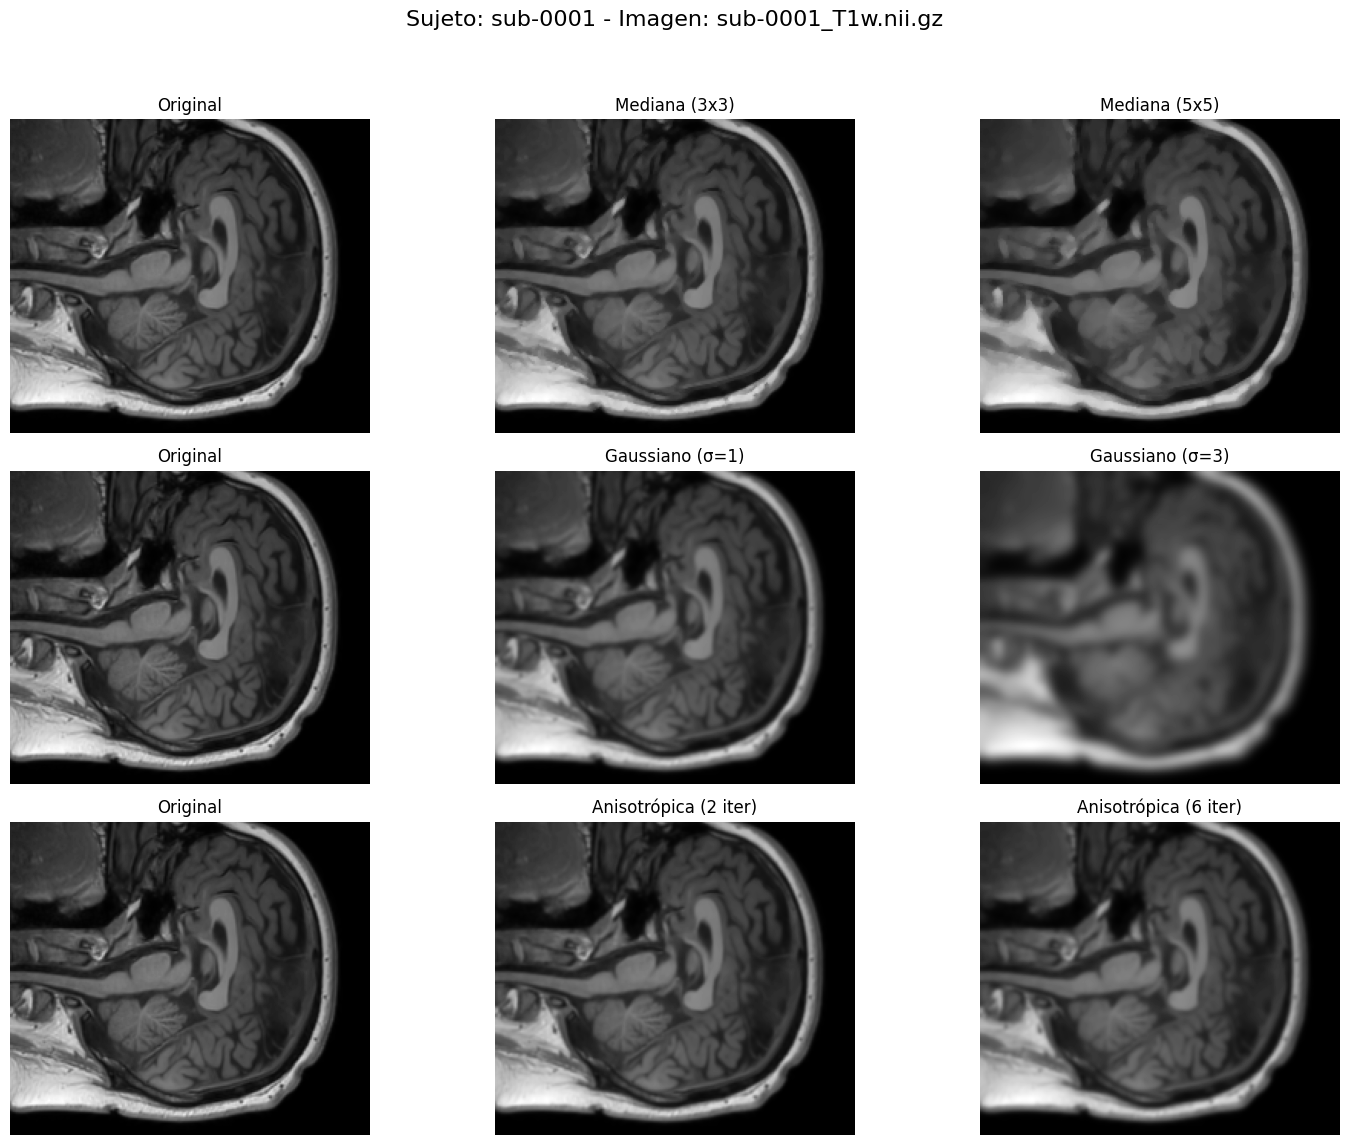

In [49]:
ruta_sujeto1 = "DATA\\BIDS\\sub-0001"
procesar_sujeto(ruta_sujeto1)

<h3>Sujeto Dos<h3>

Procesando DATA\BIDS\sub-0002\anat\sub-0002_FLAIR.nii.gz


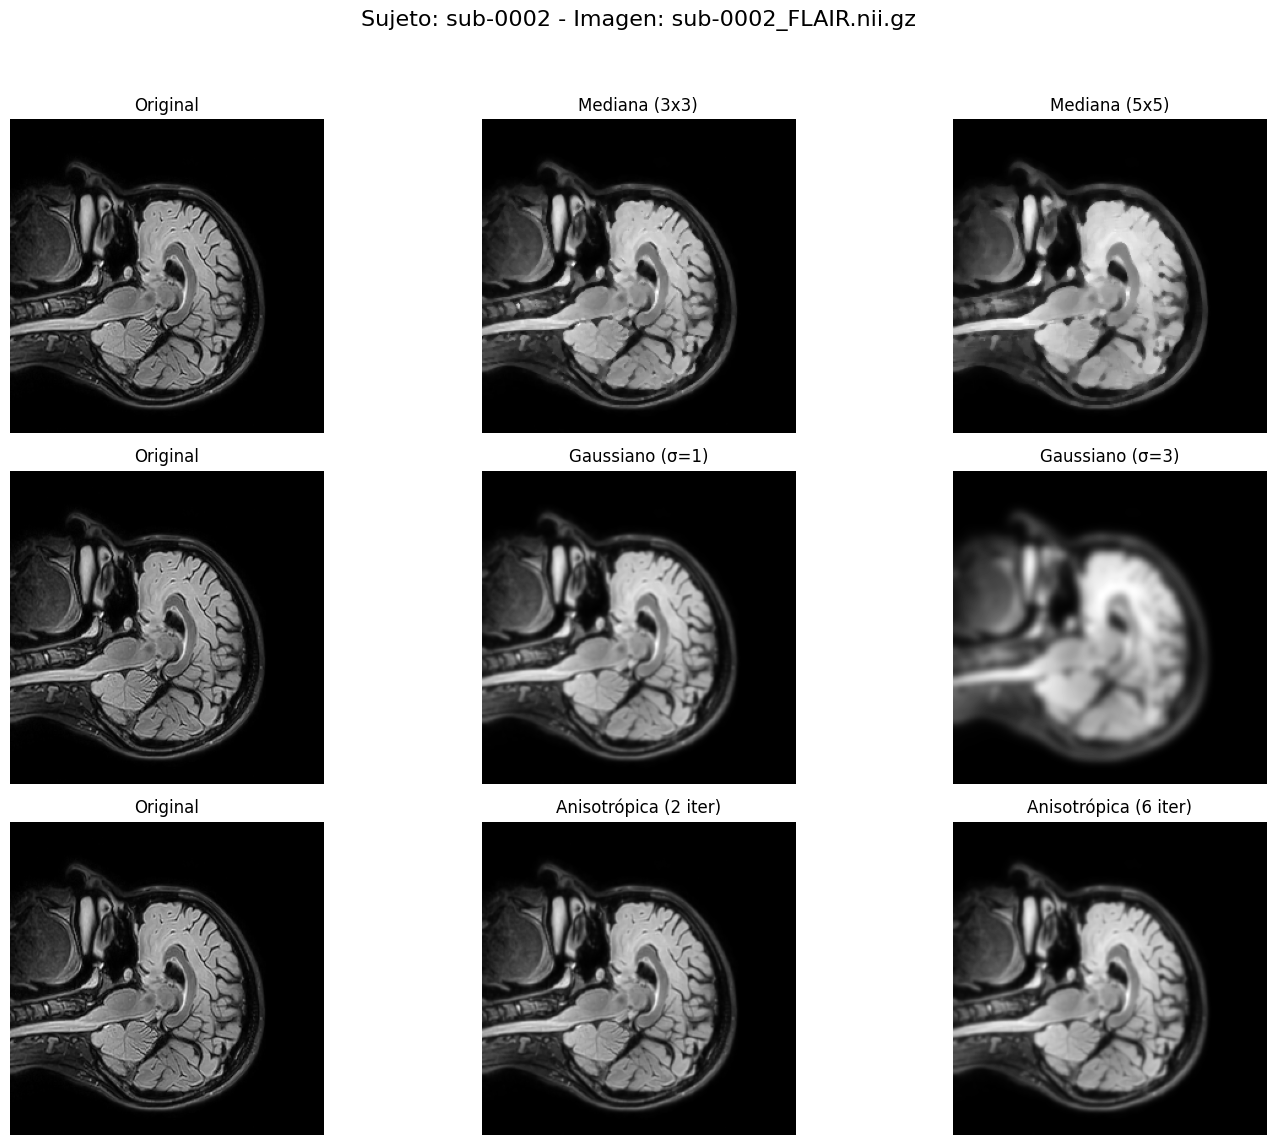

Procesando DATA\BIDS\sub-0002\anat\sub-0002_T1w.nii.gz


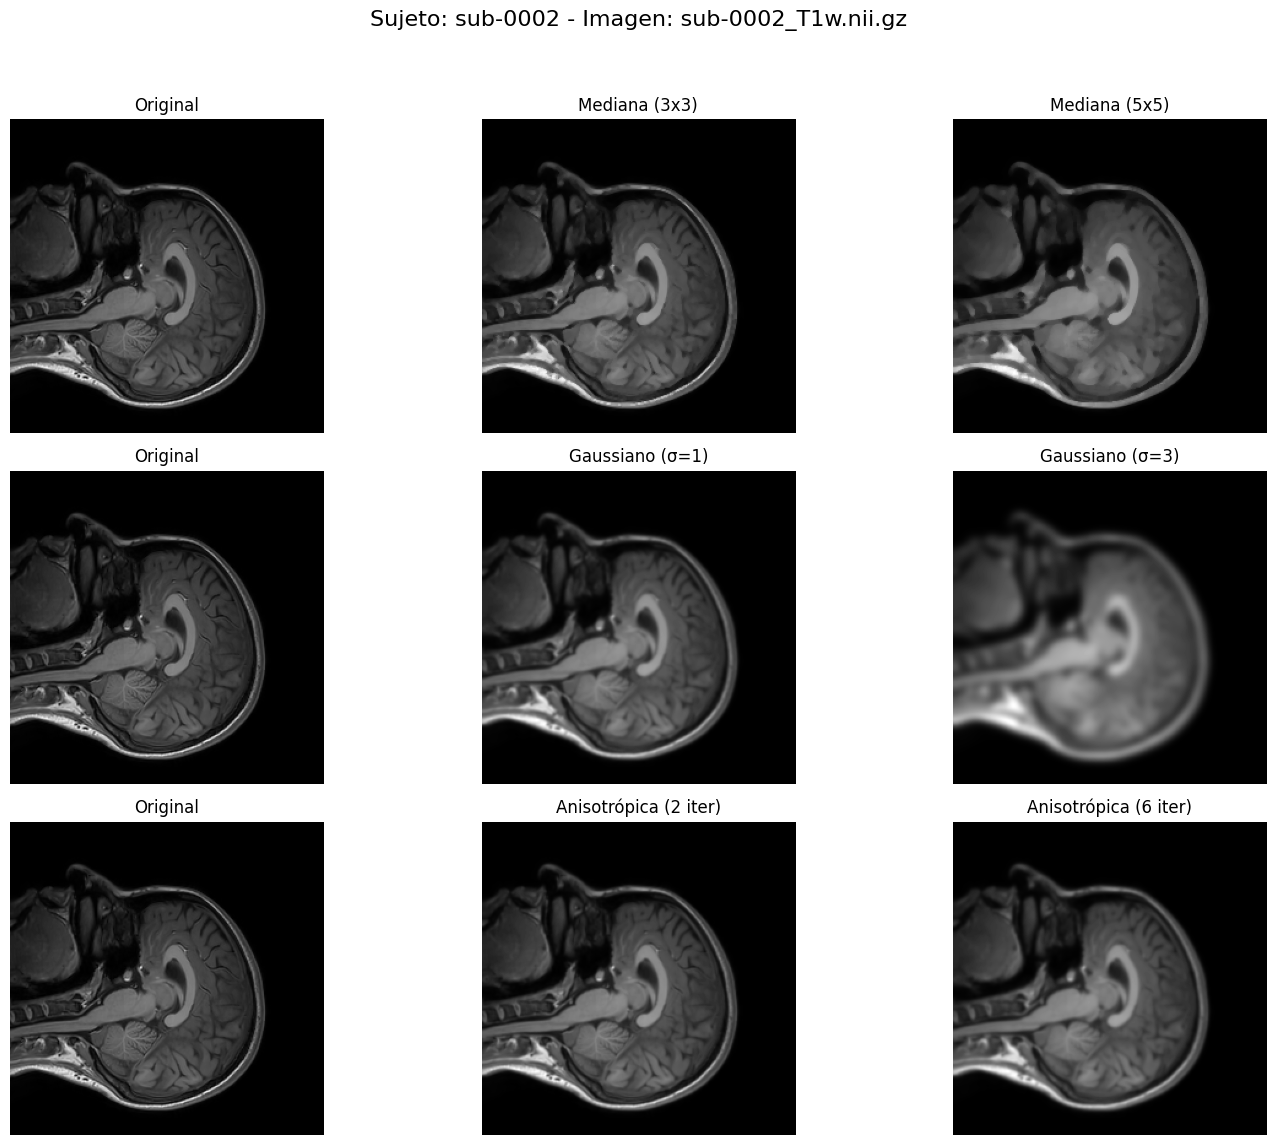

In [48]:
ruta_sujeto2 = "DATA\\BIDS\\sub-0002"
procesar_sujeto(ruta_sujeto2)

<h3>Sujeto Tres<h3>

Procesando DATA\BIDS\sub-0003\anat\sub-0003_echo-1_T1w.nii.gz


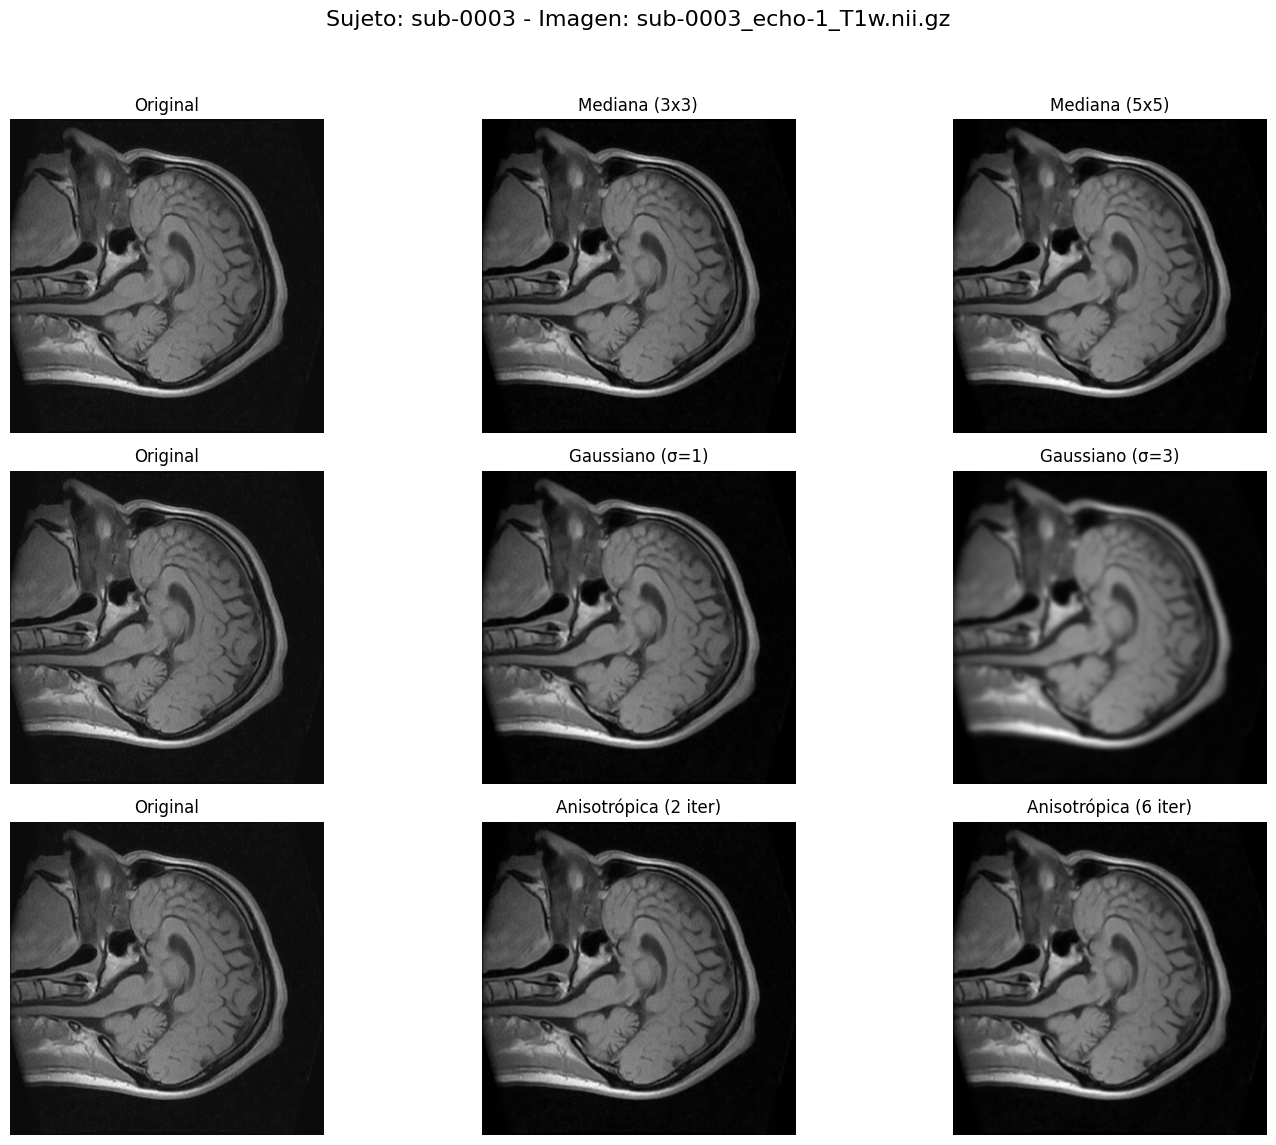

In [47]:
ruta_sujeto3 = "DATA\\BIDS\\sub-0003"
procesar_sujeto(ruta_sujeto3)

<h3> Sujeto Cuatro<h3>

Procesando DATA\BIDS\sub-0004\anat\sub-0004_T2w.nii.gz


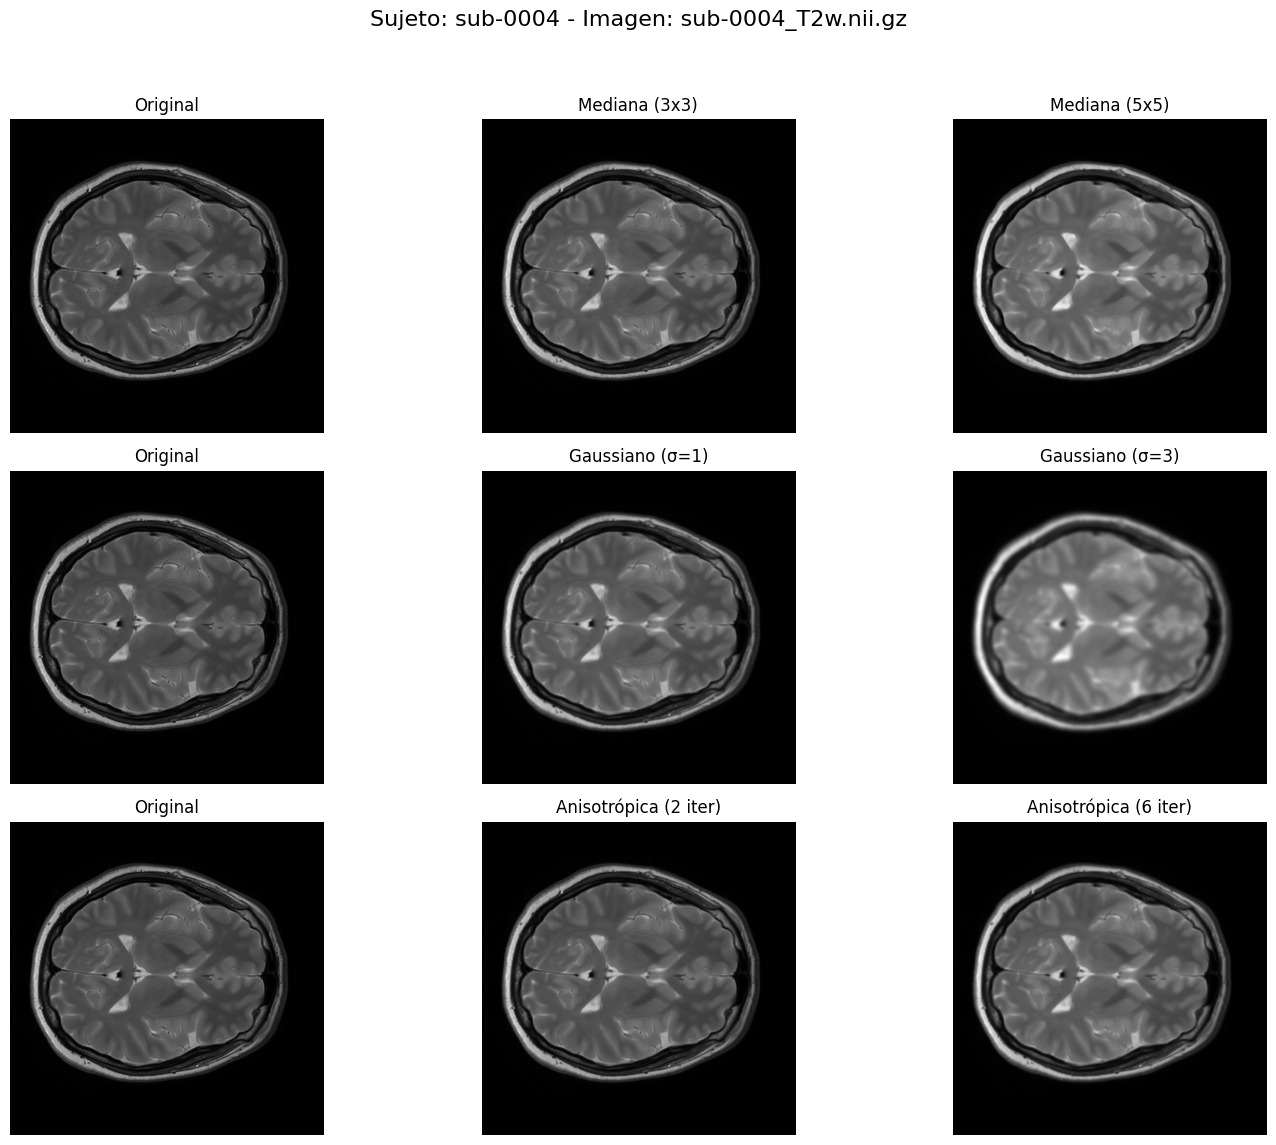

In [46]:
ruta_sujeto4 = "DATA\\BIDS\\sub-0004"
procesar_sujeto(ruta_sujeto4)

<h3> Sujeto Cinco<h3>

Procesando DATA\BIDS\sub-0005\anat\sub-0005_acq-T2COR_T2w.nii.gz


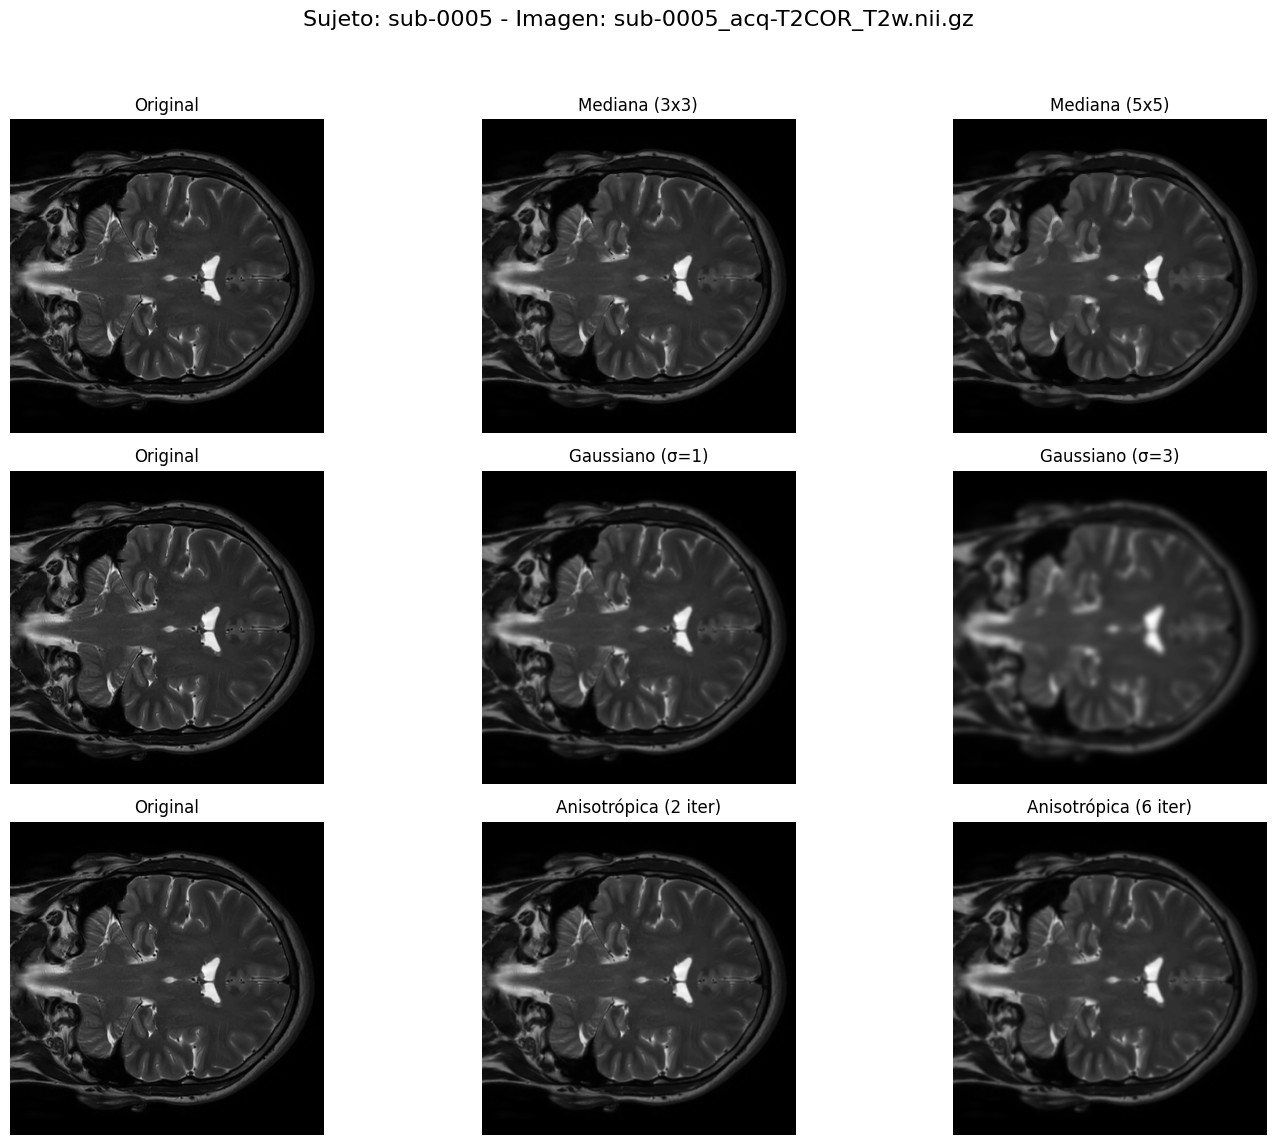

In [45]:
ruta_sujeto5 = "DATA\\BIDS\\sub-0005"
procesar_sujeto(ruta_sujeto5)

<hr>
<h3><strong>5. Comparación entre sujetos</strong></h3>

<hr>

<h3>Referencias<h3>

https://loli.github.io/medpy/index.html